# Business Understanding

## Project Domain

## Problem Statements

Harga tiket pesawat sangat bervariasi tergantung pada berbagai faktor seperti maskapai, jumlah transit, kota asal dan tujuan, serta durasi penerbangan. Fluktuasi harga ini menyulitkan penumpang dalam merencanakan anggaran dan bagi perusahaan untuk membuat strategi penetapan harga yang kompetitif.


## Goals

1. Menganalisis faktor-faktor yang mempengaruhi harga tiket pesawat.

2. Membangun model pembelajaran mesin (Artificial Neural Network) untuk memprediksi harga tiket pesawat.

3. Mencapai skor R² minimal 80% sebagai ukuran akurasi prediksi.

4. Menerapkan model ke dalam aplikasi Streamlit agar dapat digunakan oleh pengguna akhir.

## Solution Statement

# Data Understanding

Untuk mengatasi permasalahan prediksi harga tiket, kami mengembangkan sistem berbasis Artificial Neural Network (ANN) yang:

1. Melakukan eksplorasi dan pembersihan data (EDA & preprocessing).

2. Menggunakan teknik encoding dan scaling pada data kategorikal dan numerik.

3. Melatih model ANN pada data pelatihan dan mengevaluasinya dengan metrik R² dan MAE.

4. Mencapai R² ≥ 0.80 pada data uji sebagai standar kualitas prediksi.

5. Menyediakan antarmuka pengguna berbasis Streamlit agar pengguna dapat memprediksi harga tiket dengan mudah menggunakan input fitur penerbangan.

## Import data dari kaggle

In [16]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"fikariyadisolihin","key":"e9642a7443c4c9d954d1483d57aed761"}'}

In [17]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!ls ~/.kaggle

kaggle.json


In [18]:
!kaggle datasets download -d shubhambathwal/flight-price-prediction

Dataset URL: https://www.kaggle.com/datasets/shubhambathwal/flight-price-prediction
License(s): CC0-1.0


In [19]:
!unzip flight-price-prediction.zip

Archive:  flight-price-prediction.zip
  inflating: Clean_Dataset.csv       
  inflating: business.csv            
  inflating: economy.csv             


## Import Library yang dibutuhkan

In [20]:
import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import tensorflow as tf

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.layers import Dense, Activation
from tensorflow.keras import Sequential
from tensorflow.keras.optimizers import Adam

## Exploratory Data Analysis

In [21]:
df = pd.read_csv("Clean_Dataset.csv")
print(df.head())
print(df.info())

   Unnamed: 0   airline   flight source_city departure_time stops  \
0           0  SpiceJet  SG-8709       Delhi        Evening  zero   
1           1  SpiceJet  SG-8157       Delhi  Early_Morning  zero   
2           2   AirAsia   I5-764       Delhi  Early_Morning  zero   
3           3   Vistara   UK-995       Delhi        Morning  zero   
4           4   Vistara   UK-963       Delhi        Morning  zero   

    arrival_time destination_city    class  duration  days_left  price  
0          Night           Mumbai  Economy      2.17          1   5953  
1        Morning           Mumbai  Economy      2.33          1   5953  
2  Early_Morning           Mumbai  Economy      2.17          1   5956  
3      Afternoon           Mumbai  Economy      2.25          1   5955  
4        Morning           Mumbai  Economy      2.33          1   5955  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Coun

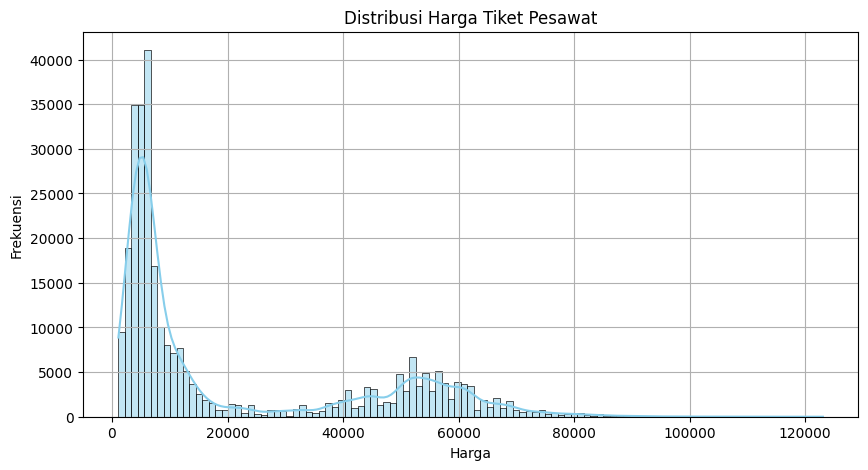

In [22]:
plt.figure(figsize=(10, 5))
sns.histplot(df['price'], kde=True, color='skyblue')
plt.title('Distribusi Harga Tiket Pesawat')
plt.xlabel('Harga')
plt.ylabel('Frekuensi')
plt.grid(True)
plt.show()

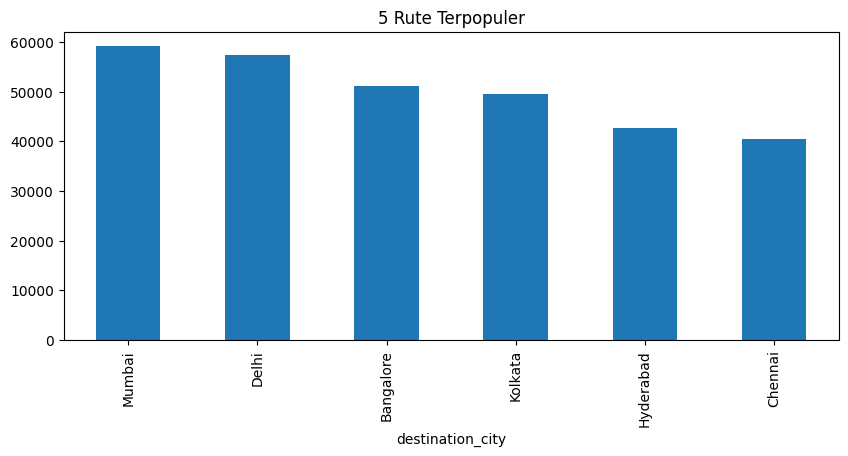

In [23]:
plt.figure(figsize=(10,4))
df['destination_city'].value_counts().head(10).plot(kind='bar')
plt.title("5 Rute Terpopuler")
plt.show()

<ipython-input-24-908a33db53fa>:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='airline', y='price', estimator='mean', ci=None, palette='viridis')
<ipython-input-24-908a33db53fa>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='airline', y='price', estimator='mean', ci=None, palette='viridis')


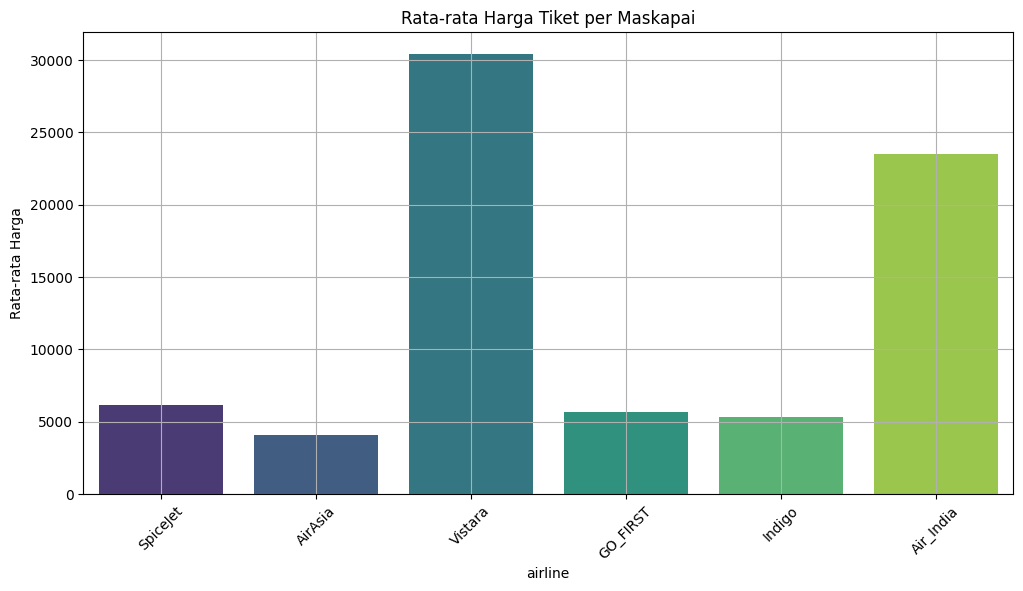

In [24]:
plt.figure(figsize=(12,6))
sns.barplot(data=df, x='airline', y='price', estimator='mean', ci=None, palette='viridis')
plt.title('Rata-rata Harga Tiket per Maskapai')
plt.xticks(rotation=45)
plt.ylabel('Rata-rata Harga')
plt.grid(True)
plt.show()


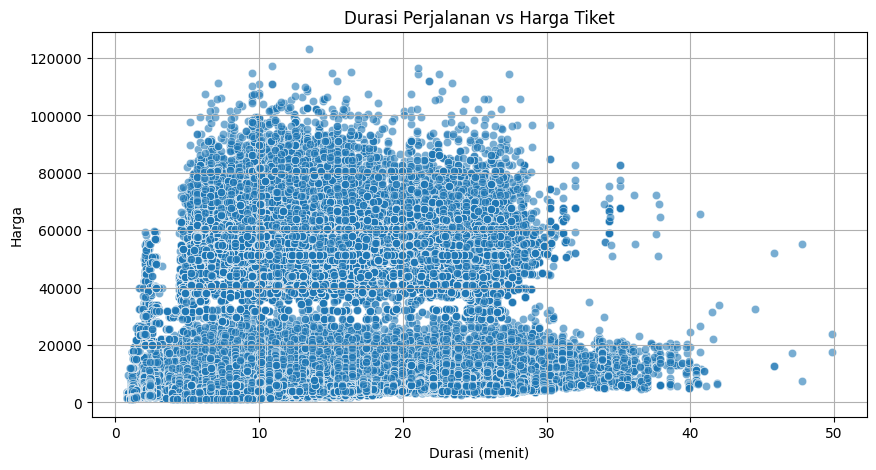

In [25]:
plt.figure(figsize=(10, 5))
sns.scatterplot(x=df['duration'], y=df['price'], alpha=0.6)
plt.title('Durasi Perjalanan vs Harga Tiket')
plt.xlabel('Durasi (menit)')
plt.ylabel('Harga')
plt.grid(True)
plt.show()

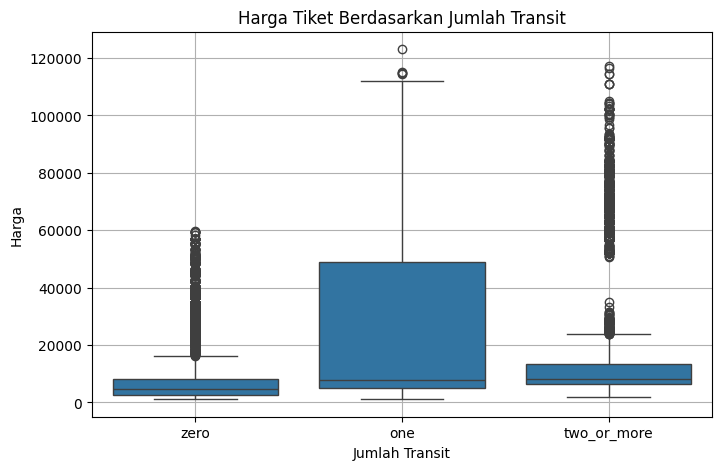

In [26]:
plt.figure(figsize=(8,5))
sns.boxplot(x='stops', y='price', data=df)
plt.title('Harga Tiket Berdasarkan Jumlah Transit')
plt.xlabel('Jumlah Transit')
plt.ylabel('Harga')
plt.grid(True)
plt.show()

# Data Preparation

In [27]:
df = df.drop(['stops', 'days_left', 'flight'], axis=1)

In [28]:
print("Jumlah baris sebelum dropna:", len(df))
df = df.dropna()
print("Jumlah baris setelah dropna:", len(df))

Jumlah baris sebelum dropna: 300153
Jumlah baris setelah dropna: 300153


In [29]:
label_cols = ['airline', 'source_city', 'destination_city']
le = LabelEncoder()
for col in label_cols:
    df[col] = le.fit_transform(df[col])

In [30]:
X = df.drop('price', axis=1)
y = df['price']

In [31]:
print("Kolom bertipe object/string:")
print(df.select_dtypes(include='object').columns)



Kolom bertipe object/string:
Index(['departure_time', 'arrival_time', 'class'], dtype='object')


In [32]:
# Label encoding untuk semua kolom bertipe objek
from sklearn.preprocessing import LabelEncoder

label_cols = df.select_dtypes(include='object').columns

le = LabelEncoder()
for col in label_cols:
    df[col] = le.fit_transform(df[col])


In [33]:
X = df.drop('price', axis=1)
y = df['price']

In [34]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [35]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

# Modeling

In [36]:
model = Sequential()
model.add(Dense(256, input_dim=X_train.shape[1], activation='relu'))
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(1))


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [37]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/50
6754/6754 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - loss: 142125328.0000 - mae: 6513.0605 - val_loss: 50951868.0000 - val_mae: 4649.0859
Epoch 2/50
6754/6754 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - loss: 45317100.0000 - mae: 4399.8091 - val_loss: 36327380.0000 - val_mae: 3993.1023
Epoch 3/50
6754/6754 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - loss: 33831684.0000 - mae: 3867.8445 - val_loss: 34098776.0000 - val_mae: 3896.1006
Epoch 4/50
6754/6754 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - loss: 32621584.0000 - mae: 3795.5298 - val_loss: 32919356.0000 - val_mae: 3771.8984
Epoch 5/50
6754/6754 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - loss: 32337520.0000 - mae: 3760.6492 - val_loss: 32910752.0000 - val_mae: 3778.7639
Epoch 6/50
6754/6754 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - loss: 31473460.0000 - mae: 3713.4128 - val_loss: 32137910.0000 - val_mae: 3786.4211
Epoch 7/50
6754/6754 ━━━━━━━━━━━━━━━━━━━━ 22s 3ms/step - loss: 31355922.0000 - mae: 3699.3718 - val_loss: 31494560.0000 - val_mae: 3734.2507
Epoch 8/50
6

# Evaluation

In [38]:
from sklearn.metrics import mean_absolute_error, r2_score

y_pred = model.predict(X_test).flatten()
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"Akurasi (R² Score): {r2 * 100:.2f}%")
print(f"MAE: {mae:.2f}")


1876/1876 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
Akurasi (R² Score): 95.76%
MAE: 3000.37


# Deployment

## Model Simulation

In [ ]:
model = tf.keras.models.load_model("flight_price_ann_model.h5", compile=False)
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

Saved artifact at '/tmp/tmp28b65btr'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 8), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  134623867056016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134623867055632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134624062193936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134624062195664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134624062195472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134624062196432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134624062196240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134624062197200: TensorSpec(shape=(), dtype=tf.resource, name=None)


## Save Model

In [ ]:
with open("flight_price_model.tflite", "wb") as f:
    f.write(tflite_model)